* Draft: 2021-03-11 (Thu)
# Breast Cancer Dataset with XGBoost

## Execusitve Summary
### Data: Breast Cancer Dataset
* also called breast cancer wisconsin dataset.
* [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data), Kaggle Dataset
  * Predict whether the cancer is benign or malignant
* [Breast Cancer Wisconsin (Diagnostic) Data Set](https://archive.ics.uci.edu/ml/datasets/Breast+Cancer+Wisconsin+(Diagnostic)), UCI Machine Learning Repository
  * Abstract: Diagnostic Wisconsin Breast Cancer Database
  * Data Set Information:
    * Features are computed from a digitized image of a fine needle aspirate (FNA) of a breast mass.
    * [K. P. Bennett, "Decision Tree Construction Via Linear Programming." Proceedings of the 4th Midwest Artificial Intelligence and Cognitive Science Society, pp. 97-101, 1992]
      * Separating plane described above was obtained using Multisurface Method-Tree (MSM-T), a classification method which uses linear programming to construct a decision tree.
      * Relevant features were selected using an exhaustive search in the space of 1-4 features and 1-3 separating planes.
      * The actual linear program used to obtain the separating plane in the 3-dimensional space is that described in:
        * [K. P. Bennett and O. L. Mangasarian: "Robust Linear Programming Discrimination of Two Linearly Inseparable Sets", Optimization Methods and Software 1, 1992, 23-34].

### Machine Learning Algorithm: XGBoost
* 트리 기반의 앙상블 기법
  * 구체적으로 GBM (Gradient Boosting Machine)기반
    * GBM
      * 장점
      * 단점
        * 느린 수행시간
        * 과적합 (규제 부재)
* 병렬 CPU 환경에서 빠르게 학습 가능
* 예측 성능이 좋아 경쟁에서 상위 랭킹에 자주 등장

## Next
* Kaggle에서 같은 코드를 작성해 보세요.
  * [Breast Cancer Wisconsin (Diagnostic) Data Set](https://www.kaggle.com/uciml/breast-cancer-wisconsin-data), Kaggle Dataset
* Data acquisition 부분의 코딩이 조금 달라집니다.
  * 참고코드: https://www.kaggle.com/aimldl/breast-cancer-dataset-xgboost

## Youtube Videos
* [XGBoost, LightGBM](https://youtu.be/4Jz4_IOgS4c), Youtube, 이수안컴퓨터연구소, 2020-10-24 [41:06]
  * 파이썬 기반 XGBoost

## Hands-on

### Hyperparameters

In [2]:
# train_test_split
test_size = 0.2
random_state = 51
# train_test_split

# xgb.train
params = {
    'max_depth': 3,
    'eta': 0.1,
    'objective': 'binary:logistic',
    'eval_metric': 'logloss',
    'early_stopping': 100
}
num_boost_round = 400
early_stopping_rounds = 100
# xgb.train

### 1. Data Acquisition

* [sklearn.datasets.load_breast_cancer](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_breast_cancer.html)

In [3]:
from sklearn.datasets import load_breast_cancer

breast_cancer_dataset = load_breast_cancer()
dataset = breast_cancer_dataset

## 2. Data Exploration
This step is skipped.

In [12]:
type( dataset.data )

numpy.ndarray

In [13]:
dataset.data

array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
        1.189e-01],
       [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
        8.902e-02],
       [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
        8.758e-02],
       ...,
       [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
        7.820e-02],
       [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
        1.240e-01],
       [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
        7.039e-02]])

In [18]:
dataset.data.shape

(569, 30)

In [19]:
dataset.target

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
       1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
       1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
       1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0,
       0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0,

### 3. Data Preparation
* [sklearn.model_selection.train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(dataset.data, dataset.target, test_size=test_size, random_state=random_state )

* [Docs](https://xgboost.readthedocs.io/en/latest/index.html) > [XGBoost Python Package](https://xgboost.readthedocs.io/en/latest/python/index.html) > [Python Package Introduction](https://xgboost.readthedocs.io/en/latest/python/python_intro.html)

In [ ]:
import xgboost as xgb

dtrain = xgb.DMatrix(data=X_train, label=y_train)
dtest = xgb.DMatrix(data=X_test, label=y_test)

Change the splitted data format for XGBoost.

In [ ]:
print( type(X_train), type(X_test), type(y_train), type(y_test) )

<class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [ ]:
print( type(dtrain), type(dtest) )

<class 'xgboost.core.DMatrix'> <class 'xgboost.core.DMatrix'>


### 4. Feature Engineering
is not applied at this time.

### 5. Model Selection

XGBoost will be used for this example.

### 6. Model Training

In [ ]:
evals = [(dtrain, 'train'), (dtest, 'eval')]
xgb_model = xgb.train(params=params, dtrain=dtrain, num_boost_round=num_boost_round, early_stopping_rounds=early_stopping_rounds, evals=evals)

[0]	train-logloss:0.609436	eval-logloss:0.610101
Multiple eval metrics have been passed: 'eval-logloss' will be used for early stopping.

Will train until eval-logloss hasn't improved in 100 rounds.
[1]	train-logloss:0.540471	eval-logloss:0.540739
[2]	train-logloss:0.482113	eval-logloss:0.484899
[3]	train-logloss:0.433653	eval-logloss:0.43922
[4]	train-logloss:0.39072	eval-logloss:0.39791
[5]	train-logloss:0.353717	eval-logloss:0.362107
[6]	train-logloss:0.322225	eval-logloss:0.329962
[7]	train-logloss:0.292921	eval-logloss:0.301791
[8]	train-logloss:0.267306	eval-logloss:0.278011
[9]	train-logloss:0.244087	eval-logloss:0.25775
[10]	train-logloss:0.22517	eval-logloss:0.240372
[11]	train-logloss:0.208073	eval-logloss:0.222709
[12]	train-logloss:0.191772	eval-logloss:0.207948
[13]	train-logloss:0.17746	eval-logloss:0.195312
[14]	train-logloss:0.164082	eval-logloss:0.184597
[15]	train-logloss:0.152497	eval-logloss:0.171834
[16]	train-logloss:0.141981	eval-logloss:0.161516
[17]	train-loglo

### 7. Model Evaluation
#### 7.1. Predictions

In [ ]:
import numpy as np

predictions = xgb_model.predict(dtest)
print(predictions[:10])
print(np.round(predictions[:10], 3))

[9.9955374e-01 9.9917752e-01 8.6196855e-04 9.9485481e-01 5.4615230e-04
 9.8911756e-01 9.9485010e-01 9.9818277e-01 9.6617907e-01 7.9452908e-01]
[1.    0.999 0.001 0.995 0.001 0.989 0.995 0.998 0.966 0.795]


In [ ]:
y_hat_test = [1 if p > 0.5 else 0 for p in predictions]
print(y_hat_test[:10])

[1, 1, 0, 1, 0, 1, 1, 1, 1, 1]


### 7.2. Evaluation metrics: Accuracy, Precision, Recall

* [sklearn.metrics.accuracy_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.accuracy_score.html)
* [sklearn.metrics.precision_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.precision_score.html)
* [sklearn.metrics.recall_score](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.recall_score.html)

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score

print('Accuracy: {}'.format(accuracy_score(y_test, y_hat_test)))    # 정확도
print('Precision: {}'.format(precision_score(y_test, y_hat_test)))  # 정밀도
print('Recall: {}'.format(recall_score(y_test, y_hat_test)))        # 재현율

Accuracy: 0.9736842105263158
Precision: 0.972972972972973
Recall: 0.9863013698630136


### 7.3. Visualization: Feature Importance

* [Docs](https://xgboost.readthedocs.io/en/latest/index.html) > [XGBoost Python Package](https://xgboost.readthedocs.io/en/latest/python/index.html) > [Python Package Introduction](https://xgboost.readthedocs.io/en/latest/python/python_intro.html) > [Plotting](https://xgboost.readthedocs.io/en/latest/python/python_intro.html#plotting)

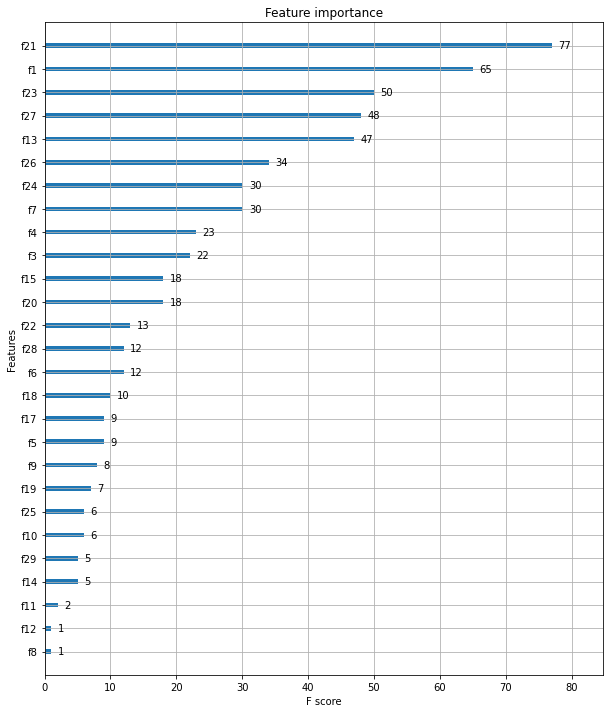

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 12))
xgb.plot_importance(xgb_model, ax=ax)

### 7.4. Visualization: Learned Tree

* [How to Visualize Gradient Boosting Decision Trees With XGBoost in Python](https://machinelearningmastery.com/visualize-gradient-boosting-decision-trees-xgboost-python/) > [Plot a Single XGBoost Decision Tree](https://machinelearningmastery.com/visualize-gradient-boosting-decision-trees-xgboost-python/), Machine Learning Mastery, 2020-08-27

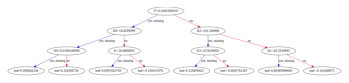

In [ ]:
import graphviz

dot_data = xgb.to_graphviz(xgb_model)
xgb.plot_tree(xgb_model, num_trees=2)
plt.show()

If the orientation of the tree is changed from left to right,

In [20]:
xgb.plot_tree(xgb_model, num_trees=2, rankdir='LR')
plt.show()

NameError: ignored

A clear version is below.

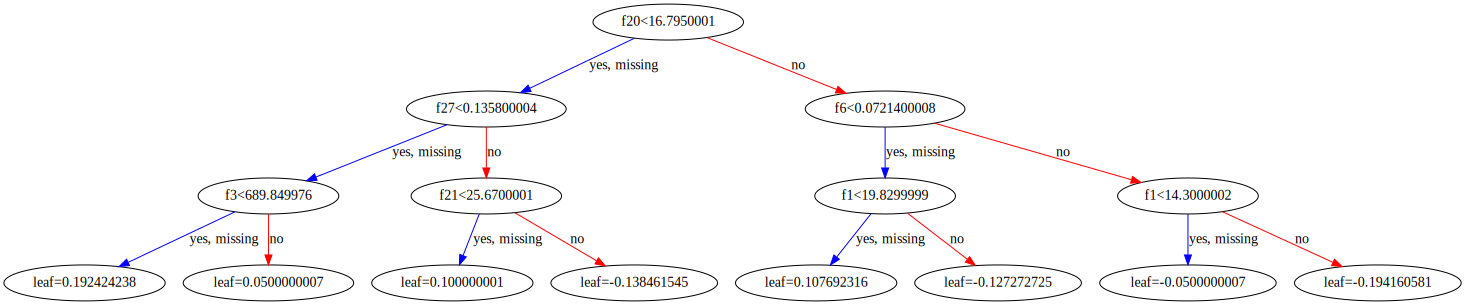

In [ ]:
#import graphviz

dot_data = xgb.to_graphviz(xgb_model)
graph = graphviz.Source(dot_data)
graph

### 7.5. Cross-validation
TODO: 정리할 것

#### XGBClassifier with Cross-Validation

In [ ]:
from xgboost.sklearn import XGBClassifier

num_estimators = 400
learning_rate = 0.1
max_depth = 3

xgbc = XGBClassifier(n_estimators=num_estimators, learning_rate=learning_rate, max_depth=max_depth)
xgbc.fit(X_train, y_train)

XGBClassifier(base_score=0.5, booster='gbtree', colsample_bylevel=1,
              colsample_bynode=1, colsample_bytree=1, gamma=0,
              learning_rate=0.1, max_delta_step=0, max_depth=3,
              min_child_weight=1, missing=None, n_estimators=400, n_jobs=1,
              nthread=None, objective='binary:logistic', random_state=0,
              reg_alpha=0, reg_lambda=1, scale_pos_weight=1, seed=None,
              silent=None, subsample=1, verbosity=1)

In [21]:
predictions = xgbc.predict(X_test)
print(predictions[:10])

NameError: ignored

In [ ]:
xgbc.predict_proba(X_test)[:10]

array([[1.3589859e-04, 9.9986410e-01],
       [3.4952164e-04, 9.9965048e-01],
       [9.9977070e-01, 2.2932758e-04],
       [3.3007264e-03, 9.9669927e-01],
       [9.9984652e-01, 1.5346476e-04],
       [9.4124675e-03, 9.9058753e-01],
       [1.5947223e-03, 9.9840528e-01],
       [8.2176924e-04, 9.9917823e-01],
       [1.8733263e-02, 9.8126674e-01],
       [1.5315890e-01, 8.4684110e-01]], dtype=float32)

In [ ]:
preds_proba = xgbc.predict_proba(X_test)[:,1]
print(preds_proba[:10])

[9.9986410e-01 9.9965048e-01 2.2932758e-04 9.9669927e-01 1.5346476e-04
 9.9058753e-01 9.9840528e-01 9.9917823e-01 9.8126674e-01 8.4684110e-01]


* [sklearn.model_selection.cross_validate](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_validate.html)
  
> Evaluate metric(s) by cross-validation and also record fit/score times.

In [ ]:
from sklearn.model_selection import cross_validate

cross_val = cross_validate(
    estimator=xgbc,
    X=dataset.data,
    y=dataset.target,
    cv=5
)
cross_val

{'fit_time': array([0.24290133, 0.23569322, 0.26062584, 0.23468184, 0.23943019]),
 'score_time': array([0.00163627, 0.0015955 , 0.00179958, 0.00154614, 0.00205112]),
 'test_score': array([0.96491228, 0.96491228, 0.99122807, 0.97368421, 0.97345133])}

In [ ]:
print('average fit time: {} (+/- {})'.format( cross_val['fit_time'].mean(), cross_val['fit_time'].std()))
print('average score time: {} (+/- {})'.format( cross_val['score_time'].mean(), cross_val['score_time'].std()))
print('average test score: {} (+/- {})'.format( cross_val['test_score'].mean(), cross_val['test_score'].std()))

average fit time: 0.24266648292541504 (+/- 0.009438730019687067)
average score time: 0.0017257213592529296 (+/- 0.0001836001028376763)
average test score: 0.9736376339077782 (+/- 0.009609619188189153)


## Appendix.

The codes in the recommended Youtube video fail to run if you type them as they are. Most errors are import errors which can be fixed by importing the appropriate packages. 

However the following error requires more than simply importing the right package.

### Problem

```python
print('Accuracy: {}'.format(accuracy_score(y_test, predictions)))    # 정확도
print('Precision: {}'.format(precision_score(y_test, predictions)))  # 정밀도
print('Recall: {}'.format(recall_score(y_test, predictions)))        # 재현율
```

```bash
---------------------------------------------------------------------------
ValueError                                Traceback (most recent call last)
<ipython-input-16-37fc48131d22> in <module>()
      3 from sklearn.metrics import recall_score
      4 
----> 5 print('Accuracy: {}'.format(accuracy_score(y_test, predictions)))    # 정확도
      6 print('Precision: {}'.format(precision_score(y_test, predictions)))  # 정밀도
      7 print('Recall: {}'.format(recall_score(y_test, predictions)))        # 재현율

1 frames
/usr/local/lib/python3.7/dist-packages/sklearn/metrics/_classification.py in _check_targets(y_true, y_pred)
     88     if len(y_type) > 1:
     89         raise ValueError("Classification metrics can't handle a mix of {0} "
---> 90                          "and {1} targets".format(type_true, type_pred))
     91 
     92     # We can't have more than one value on y_type => The set is no more needed

ValueError: Classification metrics can't handle a mix of binary and continuous targets
```

### Hint
Google search: ValueError: Classification metrics can't handle a mix of binary and continuous targets

* [Accuracy Score ValueError: Can't Handle mix of binary and continuous target](https://stackoverflow.com/questions/38015181/accuracy-score-valueerror-cant-handle-mix-of-binary-and-continuous-target), stackoverflow

> This is my true Data :
>
> ```py
> array([1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0])
> ```
>
> **My predicted Data:**
>
> ```py
> array([ 0.07094605,  0.1994941 ,  0.19270157,  0.13379635,  0.04654469,
>     0.09212494,  0.19952108,  0.12884365,  0.15685076, -0.01274453,
>     0.32167554,  0.32167554, -0.10023553,  0.09819648, -0.06755516,
>     0.25390082,  0.17248324])
> ```
>
> **My code:**
>
> ```py
> accuracy_score(y_true, y_pred, normalize=False)
> ```
>
> **Error message:**
>
> ```py
> ValueError: Can't handle mix of binary and continuous target
> ```

### Solution

```python
print('Accuracy: {}'.format(accuracy_score(y_test, preds)))    # 정확도
print('Precision: {}'.format(precision_score(y_test, preds)))  # 정밀도
print('Recall: {}'.format(recall_score(y_test, preds)))        # 재현율
```
